In [1]:
import pandas as pd

meta_data = pd.read_csv(r"C:\Users\koush\Desktop\GenAi project folder\meta_index.csv")
print(meta_data)

                                            file      label category      app  \
0             genai_chatgpt_audio_01_packets.csv      genai      NaN  chatgpt   
1             genai_chatgpt_audio_02_packets.csv      genai      NaN  chatgpt   
2              genai_chatgpt_text_01_packets.csv      genai      NaN  chatgpt   
3              genai_chatgpt_text_02_packets.csv      genai      NaN  chatgpt   
4              genai_chatgpt_text_03_packets.csv      genai      NaN  chatgpt   
..                                           ...        ...      ...      ...   
101      non_genai_stream_youtube_12_packets.csv  non_genai   stream  youtube   
102      non_genai_stream_youtube_13_packets.csv  non_genai   stream  youtube   
103      non_genai_stream_youtube_14_packets.csv  non_genai   stream  youtube   
104  non_genai_audio_calling_zoom_01_packets.csv  non_genai  calling     zoom   
105  non_genai_video_calling_zoom_01_packets.csv  non_genai  calling     zoom   

      mode  run_id  
0    a

In [2]:
meta = meta_data.copy()
print(meta.columns)
print('rows:',len(meta))

Index(['file', 'label', 'category', 'app', 'mode', 'run_id'], dtype='object')
rows: 106


In [3]:
import os
folder_path = r"C:\Users\koush\Desktop\GenAi project folder\CSV"
one_file= meta["file"].iloc[0]
file_path = os.path.join(folder_path,one_file)
df = pd.read_csv(file_path)
print(df)

         No.        Time          Source     Destination Protocol  Length  \
0          1    0.000000  192.168.137.80   192.168.137.1      DNS      74   
1          2    0.001659   192.168.137.1  192.168.137.80      DNS     120   
2          3    0.081983  192.168.137.80   192.168.137.1      DNS      78   
3          4    0.082496  192.168.137.80   192.168.137.1      DNS      74   
4          5    0.082806  192.168.137.80    104.18.32.47      TCP      74   
...      ...         ...             ...             ...      ...     ...   
36052  36053  332.351875  192.168.137.80    4.151.200.38      SSL     180   
36053  36054  332.369503  192.168.137.80    4.151.200.38      SSL     179   
36054  36055  332.388743  192.168.137.80    4.151.200.38      SSL     173   
36055  36056  332.413717  192.168.137.80    4.151.200.38      SSL     170   
36056  36057  332.461600    4.151.200.38  192.168.137.80      TCP      66   

                                                    Info  
0               

In [4]:
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
df = df.dropna(subset=["Time"])

In [5]:
total_packets=len(df)
duration_sec=df["Time"].max()-df["Time"].min()

In [6]:
print("File:", one_file)
print("Total packets:", total_packets)
print("Duration (sec):", duration_sec)
print("Time sorted?", df["Time"].is_monotonic_increasing)

File: genai_chatgpt_audio_01_packets.csv
Total packets: 36057
Duration (sec): 332.4616
Time sorted? True


In [7]:
df["Source"].value_counts().head(10)

Source
16.15.191.220      14814
192.168.137.80     12459
104.21.86.57        2024
4.151.200.38        1532
104.18.9.181        1155
172.64.155.214       920
172.203.39.49        629
172.214.226.198      497
172.66.147.128       482
104.18.32.47         262
Name: count, dtype: int64

In [8]:
df["Destination"].value_counts().head(10)

Destination
192.168.137.80     23451
16.15.191.220       3868
4.151.200.38        3456
172.214.226.198      985
172.64.155.214       858
172.203.39.49        764
104.21.86.57         701
104.18.9.181         565
104.18.32.47         184
172.66.147.128       180
Name: count, dtype: int64

In [9]:
import ipaddress
import numpy as np

def is_private_ip(ip):
    try:
        return ipaddress.ip_address(ip).is_private
    except:
        return False


In [10]:
src_counts = df["Source"].value_counts()
dst_counts = df["Destination"].value_counts()

common_ips = set(src_counts.index).intersection(set(dst_counts.index))
private_common = [ip for ip in common_ips if is_private_ip(ip)]

In [11]:
ip_scores = {
    ip: src_counts.get(ip, 0) + dst_counts.get(ip, 0)
    for ip in private_common
}

MY_IP = max(ip_scores, key=ip_scores.get)
print("Detected client IP:", MY_IP)

Detected client IP: 192.168.137.80


In [12]:
df["direction"] = np.where(df["Source"] == MY_IP, 1, -1)
# +1 = UL, -1 = DL

In [13]:
print(df)

         No.        Time          Source     Destination Protocol  Length  \
0          1    0.000000  192.168.137.80   192.168.137.1      DNS      74   
1          2    0.001659   192.168.137.1  192.168.137.80      DNS     120   
2          3    0.081983  192.168.137.80   192.168.137.1      DNS      78   
3          4    0.082496  192.168.137.80   192.168.137.1      DNS      74   
4          5    0.082806  192.168.137.80    104.18.32.47      TCP      74   
...      ...         ...             ...             ...      ...     ...   
36052  36053  332.351875  192.168.137.80    4.151.200.38      SSL     180   
36053  36054  332.369503  192.168.137.80    4.151.200.38      SSL     179   
36054  36055  332.388743  192.168.137.80    4.151.200.38      SSL     173   
36055  36056  332.413717  192.168.137.80    4.151.200.38      SSL     170   
36056  36057  332.461600    4.151.200.38  192.168.137.80      TCP      66   

                                                    Info  direction  
0    

In [14]:
print(df.tail(10))

         No.        Time          Source     Destination Protocol  Length  \
36047  36048  332.148817  192.168.137.80    4.151.200.38      SSL     157   
36048  36049  332.216222    4.151.200.38  192.168.137.80      TCP      66   
36049  36050  332.216265    4.151.200.38  192.168.137.80      TCP      66   
36050  36051  332.316598  192.168.137.80    4.151.200.38      SSL     791   
36051  36052  332.329231  192.168.137.80    4.151.200.38      SSL     180   
36052  36053  332.351875  192.168.137.80    4.151.200.38      SSL     180   
36053  36054  332.369503  192.168.137.80    4.151.200.38      SSL     179   
36054  36055  332.388743  192.168.137.80    4.151.200.38      SSL     173   
36055  36056  332.413717  192.168.137.80    4.151.200.38      SSL     170   
36056  36057  332.461600    4.151.200.38  192.168.137.80      TCP      66   

                                                    Info  direction  
36047                                  Continuation Data          1  
36048  443  

In [15]:
df = df.sort_values("Time").reset_index(drop=True)

In [16]:
print(df)

         No.        Time          Source     Destination Protocol  Length  \
0          1    0.000000  192.168.137.80   192.168.137.1      DNS      74   
1          2    0.001659   192.168.137.1  192.168.137.80      DNS     120   
2          3    0.081983  192.168.137.80   192.168.137.1      DNS      78   
3          4    0.082496  192.168.137.80   192.168.137.1      DNS      74   
4          5    0.082806  192.168.137.80    104.18.32.47      TCP      74   
...      ...         ...             ...             ...      ...     ...   
36052  36053  332.351875  192.168.137.80    4.151.200.38      SSL     180   
36053  36054  332.369503  192.168.137.80    4.151.200.38      SSL     179   
36054  36055  332.388743  192.168.137.80    4.151.200.38      SSL     173   
36055  36056  332.413717  192.168.137.80    4.151.200.38      SSL     170   
36056  36057  332.461600    4.151.200.38  192.168.137.80      TCP      66   

                                                    Info  direction  
0    

In [17]:
df["iat"] = df["Time"].diff().fillna(0)

In [18]:
df[["Time", "Length", "direction", "iat"]].head()

,Time,Length,direction,iat
0,0.000000,74,1,0.000000
1,0.001659,120,-1,0.001659
2,0.081983,78,1,0.080324
3,0.082496,74,1,0.000513
4,0.082806,74,1,0.000310


In [19]:
print(df["direction"].value_counts())
print("IAT mean:", df["iat"].mean())
print("IAT max:", df["iat"].max())

direction
-1    23598
 1    12459
Name: count, dtype: int64
IAT mean: 0.009220445405885125
IAT max: 5.9439649999999915


In [20]:
import numpy as np

def pct(arr, p):
    return np.percentile(arr, p) if len(arr) > 0 else 0

ul = df[df["direction"] == 1]
dl = df[df["direction"] == -1]

duration_sec = df["Time"].max() - df["Time"].min()
total_packets = len(df)
total_bytes = df["Length"].sum()

ul_packets = len(ul)
dl_packets = len(dl)

ul_bytes = ul["Length"].sum()
dl_bytes = dl["Length"].sum()

dl_ul_byte_ratio = dl_bytes / ul_bytes if ul_bytes > 0 else 0
dl_ul_packet_ratio = dl_packets / ul_packets if ul_packets > 0 else 0

# packet sizes
pkt_size_mean = df["Length"].mean()
pkt_size_std = df["Length"].std()
pkt_size_p95 = pct(df["Length"], 95)
pkt_size_p50 = pct(df["Length"], 50)

ul_pkt_size_mean = ul["Length"].mean()
ul_pkt_size_std = ul["Length"].std()
ul_pkt_size_p95 = pct(ul["Length"], 95)
ul_pkt_size_p50 = pct(ul["Length"], 50)

dl_pkt_size_mean = dl["Length"].mean()
dl_pkt_size_std = dl["Length"].std()
dl_pkt_size_p95 = pct(dl["Length"], 95)
dl_pkt_size_p50 = pct(dl["Length"], 50)

# iat
iat_mean = df["iat"].mean()
iat_std = df["iat"].std()
iat_max = df["iat"].max()

ul_iat_mean = ul["iat"].mean()
ul_iat_std = ul["iat"].std()
ul_iat_max = ul["iat"].max()

dl_iat_mean = dl["iat"].mean()
dl_iat_std = dl["iat"].std()
dl_iat_max = dl["iat"].max()

# Unique destination count
unique_dst_ips = df["Destination"].nunique()
unique_src_ips = df["Source"].nunique()

# throughput
bytes_per_second = total_bytes / duration_sec if duration_sec > 0 else 0

features = {
    "duration_sec": duration_sec,
    "total_packets": total_packets,
    "ul_packets": ul_packets,
    "dl_packets": dl_packets,
    "ul_bytes": ul_bytes,
    "dl_bytes": dl_bytes,
    "dl_ul_byte_ratio": dl_ul_byte_ratio,
    "dl_ul_packet_ratio": dl_ul_packet_ratio,
    "pkt_size_mean": pkt_size_mean,
    "pkt_size_std": pkt_size_std,
    "pkt_size_p95": pkt_size_p95,
    "pkt_size_p50": pkt_size_p50,
    "ul_pkt_size_mean": ul_pkt_size_mean,
    "ul_pkt_size_std": ul_pkt_size_std,
    "ul_pkt_size_p95": ul_pkt_size_p95,
    "ul_pkt_size_p50": ul_pkt_size_p50,
    "dl_pkt_size_mean": dl_pkt_size_mean,
    "dl_pkt_size_std": dl_pkt_size_std,
    "dl_pkt_size_p95": dl_pkt_size_p95,
    "dl_pkt_size_p50": dl_pkt_size_p50,
    "iat_mean": iat_mean,
    "iat_std": iat_std,
    "iat_max": iat_max,
    "ul_iat_mean": ul_iat_mean,
    "ul_iat_std": ul_iat_std,
    "ul_iat_max": ul_iat_max,
    "dl_iat_mean": dl_iat_mean,
    "dl_iat_std": dl_iat_std,
    "dl_iat_max": dl_iat_max,
    "unique_src_ips": unique_src_ips,
    "unique_dst_ips": unique_dst_ips,
    "bytes_per_second": bytes_per_second,
}

features

{'duration_sec': np.float64(332.4616),
 'total_packets': 36057,
 'ul_packets': 12459,
 'dl_packets': 23598,
 'ul_bytes': np.int64(2068392),
 'dl_bytes': np.int64(24955917),
 'dl_ul_byte_ratio': np.float64(12.065371070860843),
 'dl_ul_packet_ratio': 1.8940524921743318,
 'pkt_size_mean': np.float64(749.4885597803478),
 'pkt_size_std': np.float64(565.5356112665996),
 'pkt_size_p95': np.float64(1304.0),
 'pkt_size_p50': np.float64(1234.0),
 'ul_pkt_size_mean': np.float64(166.01589212617384),
 'ul_pkt_size_std': np.float64(239.07230247226101),
 'ul_pkt_size_p95': np.float64(741.0999999999985),
 'ul_pkt_size_p50': np.float64(66.0),
 'dl_pkt_size_mean': np.float64(1057.5437325197051),
 'dl_pkt_size_std': np.float64(428.8024294641376),
 'dl_pkt_size_p95': np.float64(1304.0),
 'dl_pkt_size_p50': np.float64(1234.0),
 'iat_mean': np.float64(0.009220445405885125),
 'iat_std': np.float64(0.06342033678050159),
 'iat_max': np.float64(5.9439649999999915),
 'ul_iat_mean': np.float64(0.01574809358696531

In [21]:
import os
import pandas as pd
import numpy as np
import ipaddress

META_PATH = r"C:\Users\koush\Desktop\GenAi project folder\meta_index.csv"
CSV_FOLDER = r"C:\Users\koush\Desktop\GenAi project folder\CSV"
OUT_PATH  = r"C:\Users\koush\Desktop\GenAi project folder\features_top25.csv"

# loading meta_data
meta = pd.read_csv(META_PATH)

def is_private_ip(ip: str) -> bool:
    try:
        return ipaddress.ip_address(ip).is_private
    except Exception:
        return False

def detect_client_ip(df: pd.DataFrame) -> str:
    """Pick the private IP that appears most in both Source and Destination."""
    src_counts = df["Source"].value_counts()
    dst_counts = df["Destination"].value_counts()

    common = set(src_counts.index).intersection(set(dst_counts.index))
    private_common = [ip for ip in common if is_private_ip(ip)]

    if not private_common:
        # pick most frequent private in Source+Destination combined
        all_ips = pd.concat([df["Source"], df["Destination"]], ignore_index=True)
        priv = all_ips[all_ips.apply(is_private_ip)]
        if priv.empty:
            raise ValueError("No private IP found to identify client.")
        return priv.value_counts().index[0]

    scores = {ip: src_counts.get(ip, 0) + dst_counts.get(ip, 0) for ip in private_common}
    return max(scores, key=scores.get)

def extract_features(df: pd.DataFrame) -> dict:
    df = df.copy()
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["Length"] = pd.to_numeric(df["Length"], errors="coerce")
    df = df.dropna(subset=["Time", "Length", "Source", "Destination"])
    if df.empty:
        raise ValueError("Empty df after cleaning Time/Length.")

    # detect client ip
    client_ip = detect_client_ip(df)
    
    df = df.sort_values("Time").reset_index(drop=True)
    df["direction"] = np.where(df["Source"] == client_ip, 1, -1)  # +1 UL, -1 DL

    df["iat"] = df["Time"].diff().fillna(0.0)

    ul = df[df["direction"] == 1]
    dl = df[df["direction"] == -1]

    duration_sec = float(df["Time"].max() - df["Time"].min())
    total_packets = int(len(df))
    total_bytes = float(df["Length"].sum())

    ul_packets = int(len(ul))
    dl_packets = int(len(dl))
    ul_bytes = float(ul["Length"].sum())
    dl_bytes = float(dl["Length"].sum())

    dl_ul_byte_ratio = (dl_bytes / ul_bytes) if ul_bytes > 0 else 0.0
    dl_ul_packet_ratio = (dl_packets / ul_packets) if ul_packets > 0 else 0.0

    # packet size
    pkt_size_mean = float(df["Length"].mean())
    pkt_size_std  = float(df["Length"].std(ddof=1)) if total_packets > 1 else 0.0
    pkt_size_p95  = float(np.percentile(df["Length"].to_numpy(), 95)) if len(df) > 0 else 0.0
    pkt_size_p50  = float(np.percentile(df["Length"].to_numpy(), 50)) if len(df) > 0 else 0.0
    p95_p50 = pkt_size_p95 - pkt_size_p50

    ul_pkt_size_mean = float(ul["Length"].mean()) if ul_packets > 0 else 0.0
    ul_pkt_size_std  = float(ul["Length"].std(ddof=1)) if ul_packets > 1 else 0.0
    ul_pkt_size_p95  = float(np.percentile(ul["Length"].to_numpy(), 95)) if len(ul) > 0 else 0.0
    ul_pkt_size_p50  = float(np.percentile(ul["Length"].to_numpy(), 50)) if len(ul) > 0 else 0.0
    ul_p95_p50 = ul_pkt_size_p95 - ul_pkt_size_p50

    dl_pkt_size_mean = float(dl["Length"].mean()) if dl_packets > 0 else 0.0
    dl_pkt_size_std  = float(dl["Length"].std(ddof=1)) if dl_packets > 1 else 0.0
    dl_pkt_size_p95  = float(np.percentile(dl["Length"].to_numpy(), 95)) if len(dl) > 0 else 0.0
    dl_pkt_size_p50  = float(np.percentile(dl["Length"].to_numpy(), 50)) if len(dl) > 0 else 0.0
    dl_p95_p50 = dl_pkt_size_p95 - dl_pkt_size_p50
    
    # IAT 
    iat_mean = float(df["iat"].mean())
    iat_std  = float(df["iat"].std(ddof=1)) if total_packets > 1 else 0.0
    iat_max  = float(df["iat"].max())

    ul_iat_mean = float(ul["iat"].mean()) if ul_packets > 0 else 0.0
    ul_iat_std  = float(ul["iat"].std(ddof=1)) if ul_packets > 1 else 0.0
    ul_iat_max = float(ul["iat"].max())

    dl_iat_mean = float(dl["iat"].mean()) if dl_packets > 0 else 0.0
    dl_iat_std  = float(dl["iat"].std(ddof=1)) if dl_packets > 1 else 0.
    dl_iat_max = float(dl["iat"].max())

    # Unique src & destination count
    unique_src_ips = int(df["Source"].nunique())
    unique_dst_ips = int(df["Destination"].nunique())

    # throughput
    bytes_per_second = (total_bytes / duration_sec) if duration_sec > 0 else 0.0

    return {
        "client_ip": client_ip,

        # features
        "duration_sec": duration_sec,
        "total_packets": total_packets,
        "ul_packets": ul_packets,
        "dl_packets": dl_packets,
        "ul_bytes": ul_bytes,
        "dl_bytes": dl_bytes,
        "dl_ul_byte_ratio": dl_ul_byte_ratio,
        "dl_ul_packet_ratio": dl_ul_packet_ratio,

        "pkt_size_mean": pkt_size_mean,
        "pkt_size_std": pkt_size_std,
        "pkt_size_p95": pkt_size_p95,
        "pkt_size_p50": pkt_size_p50,
        "p95_p50": p95_p50,

        "ul_pkt_size_mean": ul_pkt_size_mean,
        "ul_pkt_size_std": ul_pkt_size_std,
        "ul_pkt_size_p95": ul_pkt_size_p95,
        "ul_pkt_size_p50": ul_pkt_size_p50,
        "ul_p95_p50": ul_p95_p50,

        "dl_pkt_size_mean": dl_pkt_size_mean,
        "dl_pkt_size_std": dl_pkt_size_std,
        "dl_pkt_size_p95": dl_pkt_size_p95,
        "dl_pkt_size_p50": dl_pkt_size_p50,
        "dl_p95_p50": dl_p95_p50,
        
        "iat_mean": iat_mean,
        "iat_std": iat_std,
        "iat_max": iat_max,

        "ul_iat_mean": ul_iat_mean,
        "ul_iat_std": ul_iat_std,
        "ul_iat_max": ul_iat_max,

        "dl_iat_mean": dl_iat_mean,
        "dl_iat_std": dl_iat_std,
        "dl_iat_max": dl_iat_max,
        
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "bytes_per_second": bytes_per_second,
    }

feature_rows = []
errors = []

for _, row in meta.iterrows():
    fname = row["file"]
    fpath = os.path.join(CSV_FOLDER, fname)
    try:
        df = pd.read_csv(fpath)
        feats = extract_features(df)
        out_row = dict(row)        
        out_row.update(feats)       
        feature_rows.append(out_row)

    except Exception as e:
        errors.append({"file": fname, "error": str(e)})

features_df = pd.DataFrame(feature_rows)

print("Extracted feature rows:", len(features_df))
print("Errors:", len(errors))
if errors:
    display(pd.DataFrame(errors).head(10))

Extracted feature rows: 106
Errors: 0


In [22]:
print(features_df)

                                            file      label category      app  \
0             genai_chatgpt_audio_01_packets.csv      genai      NaN  chatgpt   
1             genai_chatgpt_audio_02_packets.csv      genai      NaN  chatgpt   
2              genai_chatgpt_text_01_packets.csv      genai      NaN  chatgpt   
3              genai_chatgpt_text_02_packets.csv      genai      NaN  chatgpt   
4              genai_chatgpt_text_03_packets.csv      genai      NaN  chatgpt   
..                                           ...        ...      ...      ...   
101      non_genai_stream_youtube_12_packets.csv  non_genai   stream  youtube   
102      non_genai_stream_youtube_13_packets.csv  non_genai   stream  youtube   
103      non_genai_stream_youtube_14_packets.csv  non_genai   stream  youtube   
104  non_genai_audio_calling_zoom_01_packets.csv  non_genai  calling     zoom   
105  non_genai_video_calling_zoom_01_packets.csv  non_genai  calling     zoom   

      mode  run_id        c

In [23]:
extraction_path = r"C:\Users\koush\Desktop\GenAi project folder\all_features.csv"
features_df.to_csv(extraction_path, index=False)

In [24]:
import pandas as pd
import numpy as np

df_feat=features_df

print("Shape:", df_feat.shape)
print("Labels:\n", df_feat["label"].value_counts())


Shape: (106, 42)
Labels:
 label
genai        55
non_genai    51
Name: count, dtype: int64


In [25]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [26]:

print("Shape:", df_feat.shape)
print(df_feat["label"].value_counts())
df_feat.head()

Shape: (106, 42)
label
genai        55
non_genai    51
Name: count, dtype: int64


,file,label,category,app,mode,run_id,client_ip,duration_sec,total_packets,ul_packets,...,iat_max,ul_iat_mean,ul_iat_std,ul_iat_max,dl_iat_mean,dl_iat_std,dl_iat_max,unique_src_ips,unique_dst_ips,bytes_per_second
0,genai_chatgpt_audio_01_packets.csv,genai,NaN,chatgpt,audio,1,192.168.137.80,332.461600,36057,12459,...,5.943965,0.015748,0.088551,5.943965,0.005774,0.044403,2.689654,31,39,81285.504852
1,genai_chatgpt_audio_02_packets.csv,genai,NaN,chatgpt,audio,2,192.168.137.109,446.460153,56991,25072,...,0.919187,0.004693,0.006550,0.447186,0.010301,0.011554,0.919187,54,56,23226.968701
2,genai_chatgpt_text_01_packets.csv,genai,NaN,chatgpt,text,1,192.168.137.80,423.286492,4637,1832,...,17.344721,0.100521,0.548698,17.344721,0.085252,0.351864,14.637458,31,38,2427.743430
3,genai_chatgpt_text_02_packets.csv,genai,NaN,chatgpt,text,2,192.168.137.80,381.932889,7072,2908,...,8.018130,0.069919,0.349766,6.433675,0.042894,0.183274,8.018130,23,37,10372.495048
4,genai_chatgpt_text_03_packets.csv,genai,NaN,chatgpt,text,3,192.168.137.80,376.032107,4849,2147,...,8.132470,0.094811,0.441796,8.132470,0.063832,0.279323,6.512313,23,33,6246.110256


In [27]:
EXCLUDE = {
    "file",
    "label",
    "client_ip",
    "app",
    "category",
    "mode",
    "run_id",
}

feature_cols = [
    c for c in df_feat.columns
    if (c not in EXCLUDE) and (df_feat[c].dtype != "O")
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 35
['duration_sec', 'total_packets', 'ul_packets', 'dl_packets', 'ul_bytes', 'dl_bytes', 'dl_ul_byte_ratio', 'dl_ul_packet_ratio', 'pkt_size_mean', 'pkt_size_std', 'pkt_size_p95', 'pkt_size_p50', 'p95_p50', 'ul_pkt_size_mean', 'ul_pkt_size_std', 'ul_pkt_size_p95', 'ul_pkt_size_p50', 'ul_p95_p50', 'dl_pkt_size_mean', 'dl_pkt_size_std', 'dl_pkt_size_p95', 'dl_pkt_size_p50', 'dl_p95_p50', 'iat_mean', 'iat_std', 'iat_max', 'ul_iat_mean', 'ul_iat_std', 'ul_iat_max', 'dl_iat_mean', 'dl_iat_std', 'dl_iat_max', 'unique_src_ips', 'unique_dst_ips', 'bytes_per_second']


In [28]:
X = df_feat[feature_cols].values
y = (df_feat["label"] == "genai").astype(int).values

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

X shape: (106, 35)
y distribution: [51 55]


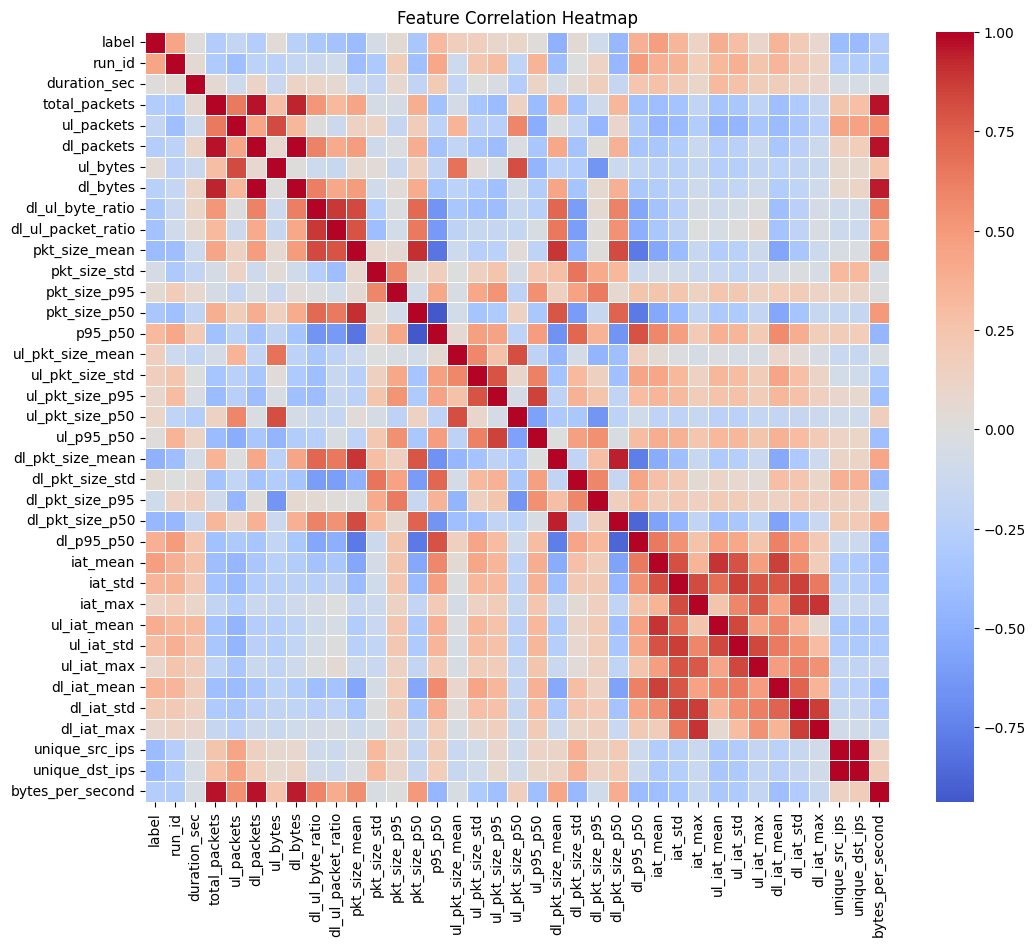

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
df_plot = df_feat.copy()
df_plot["label"] = df_plot["label"].map({
    "non_genai": 0,
    "genai": 1
})
corr = df_plot.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

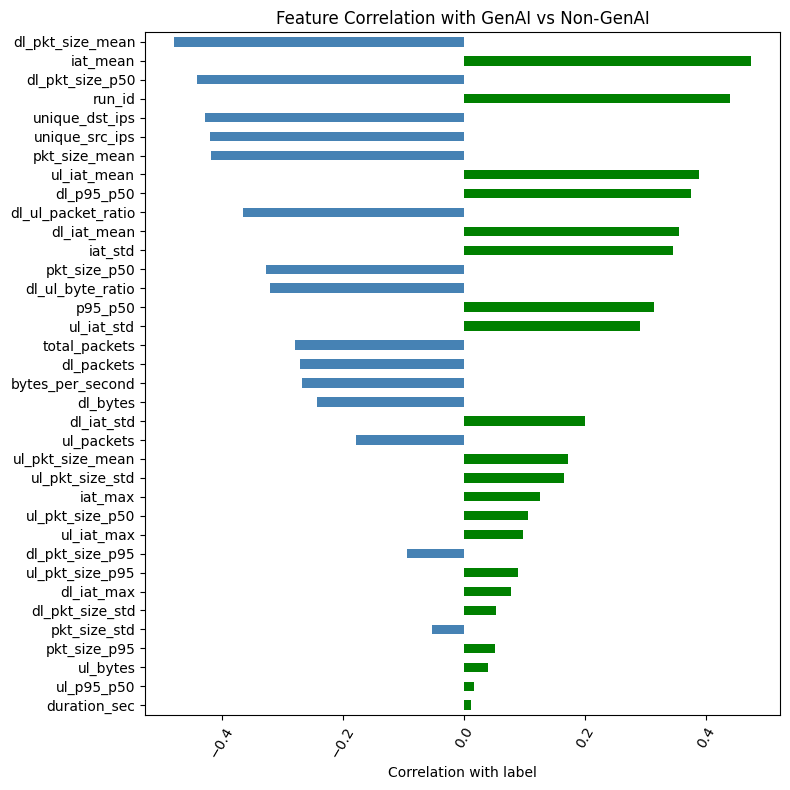

In [30]:
df_plot = df_feat.copy()

df_plot["label"] = df_plot["label"].map({
    "non_genai": 0,
    "genai": 1
})

corr = df_plot.corr(numeric_only=True)["label"].drop("label")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=True).index)
color = ["green" if v > 0 else "steelblue" for v in corr_sorted]

corr_sorted.plot(
    kind="barh",
    color=color
)

plt.xlabel("Correlation with label")
plt.title("Feature Correlation with GenAI vs Non-GenAI")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()